In [ ]:
#r "C:\Users\Para8e11um\projects\practice2026\task14\bin\Debug\net9.0\task14.dll"
#r "nuget: ScottPlot, 5.0.56"
using Microsoft.DotNet.Interactive.Formatting;
using task14;
using ScottPlot;
using System;
using System.Diagnostics;
using System.IO;
using System.Linq;
Formatter.Register(typeof(ScottPlot.Plot), (p,w) => w.Write(((ScottPlot.Plot)p).GetPngHtml(800,400)),HtmlFormatter.MimeType);

Installed Packages ScottPlot, 5.0.56

Loading extensions from `C:\Users\Para8e11um\.nuget\packages\skiasharp\2.88.9\interactive-extensions\dotnet\SkiaSharp.DotNet.Interactive.dll`

In [2]:
double chosenStep = 1e-6;
int[] threadCounts = {1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16};
double[] times = new double[threadCounts.Length];
double[] threadsArr = threadCounts.Select(t=> (double)t).ToArray();
int numRuns = 3;
var SIN = (double x) => Math.Sin(x);

for (int i = 0; i < threadCounts.Length; i++){
    int threads = threadCounts[i];

    DefiniteIntegral.Solve(-100,100,SIN,chosenStep,threads);
    Stopwatch sw = new Stopwatch();
    for(int run = 0; run < numRuns; run++){
        sw.Start();
        DefiniteIntegral.Solve(-100,100,SIN,chosenStep,threads);
        sw.Stop();
    }
    times[i] = sw.Elapsed.TotalMilliseconds / numRuns;
    Console.WriteLine($"Потоков: {threads}, ср. время: {times[i]:F2} мс");

}

Потоков: 1, ср. время: 2982.40 мс
Потоков: 2, ср. время: 1654.07 мс
Потоков: 3, ср. время: 1322.99 мс
Потоков: 4, ср. время: 1122.82 мс
Потоков: 5, ср. время: 999.39 мс
Потоков: 6, ср. время: 930.50 мс
Потоков: 7, ср. время: 883.20 мс
Потоков: 8, ср. время: 862.18 мс
Потоков: 9, ср. время: 849.58 мс
Потоков: 10, ср. время: 823.30 мс
Потоков: 11, ср. время: 800.29 мс
Потоков: 12, ср. время: 790.70 мс
Потоков: 13, ср. время: 751.59 мс
Потоков: 14, ср. время: 777.54 мс
Потоков: 15, ср. время: 777.33 мс
Потоков: 16, ср. время: 767.50 мс



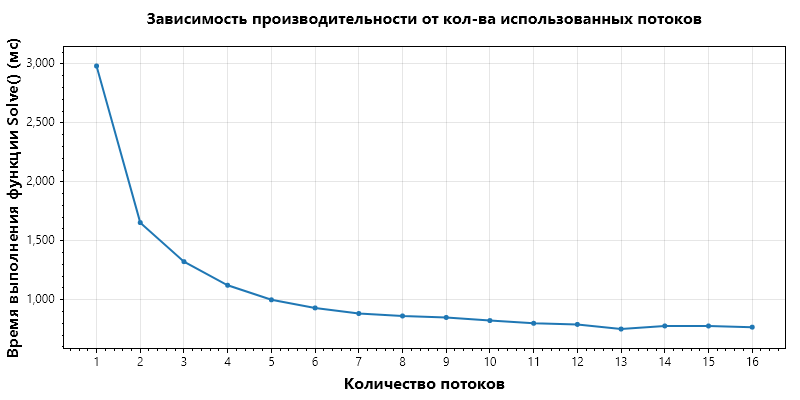

In [3]:
Plot plt = new();
var scatter = plt.Add.Scatter(threadsArr, times);
scatter.LineWidth = 2;

plt.Axes.Left.Label.Text = "Время выполнения функции Solve() (мс)";
plt.Axes.Bottom.Label.Text = "Количество потоков";
plt.Title("Зависимость производительности от кол-ва использованных потоков");

display(plt);

In [4]:
double minTime = times.Min();
int optimalThreads = threadCounts[Array.IndexOf(times,minTime)];

DefiniteIntegral.SolveSingleThread(-100,100,SIN,chosenStep);
Stopwatch swSingle = new Stopwatch();
for(int run = 0; run < numRuns; run++)
{
    swSingle.Start();
    DefiniteIntegral.SolveSingleThread(-100,100,SIN,chosenStep);
    swSingle.Stop();
}
double singleTime = swSingle.Elapsed.TotalMilliseconds / numRuns;

double diffPercent = (singleTime - minTime) / singleTime * 100;

string reportText = $@"Анализ производительности:
1.Выбранный шаг интегрирования: {chosenStep}
2.Оптимальное число потоков: {optimalThreads}
3.Время работы однопоточной версии: {singleTime:F2} мс
4.Время работы многопоточной версии: {minTime:F2} мс
5.Разница в производительности: многопоточная версия быстрее на {diffPercent:F2}%";

File.WriteAllText("report.txt",reportText);
Console.WriteLine(reportText);

Анализ производительности:
1.Выбранный шаг интегрирования: 1E-06
2.Оптимальное число потоков: 13
3.Время работы однопоточной версии: 1441.67 мс
4.Время работы многопоточной версии: 751.59 мс
5.Разница в производительности: многопоточная версия быстрее на 47.87%
